In [9]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

Load Data

In [ ]:
import json

In [14]:
with open('../../.mock/artists_data.json') as f:
    mock = json.load(f)

data = pd.DataFrame(mock)

Extracting Color

In [12]:
import requests
from io import BytesIO
from PIL import Image
import colorsys
from sklearn.cluster import KMeans


In [3]:
def load_image(url):
    response = requests.get(url, verify=False)
    return Image.open(BytesIO(response.content))

In [15]:
def get_color_palette(url:str):
    img = load_image(url).convert('RGB')
    pixels = np.array(img).reshape(-1,3)
    n_colors = 5
    km = KMeans(n_clusters=n_colors, random_state=42).fit(pixels)
    clusters = km.cluster_centers_
    count = np.bincount(km.labels_)
    proportions = count / count.sum()
    return clusters, proportions

In [16]:
def get_color(url:str, s_threshold:float=0.0, l_threshold_range:tuple=(0.0,1.0), p_threshold:float=1.0):
    palette, proportions = get_color_palette(url)

    vibrant = []
    for i, rgb in enumerate(palette):
        h, l, s = colorsys.rgb_to_hls(*np.array(rgb)/255)
        p = proportions[i]
        if s > s_threshold and l_threshold_range[0] < l < l_threshold_range[1] and p > p_threshold:
            vibrant.append((p, rgb.astype(int).tolist()))
    if vibrant:
        return max(vibrant, key=lambda x: x[0])[1]

    idx = proportions.argmax()
    return palette[idx].astype(int).tolist()

In [17]:
configs = [
    dict(),
    dict(s_threshold=0.1,l_threshold_range=(0.15,0.85),p_threshold=0.2),
    dict(s_threshold=0.08,l_threshold_range=(0.15,0.85),p_threshold=0.15),
    dict(s_threshold=0.1,l_threshold_range=(0.15,0.85),p_threshold=0.15),
]

In [18]:
for i, cfg in enumerate(configs):
    data[f'color_{i}'] = data['image_url'].apply(get_color, **cfg)

Plot Images and Colors

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
def plot_images(data:pd.DataFrame, rgb:str):
    n = len(data)

    fig, axs = plt.subplots(nrows=n, ncols=2, figsize=(2, n*1), squeeze=False)

    for i, song, in data.iterrows():

        ax1, ax2 = axs[i]
        img = load_image(song.image_url)
        ax1.imshow(img)
        ax1.set_aspect('auto')
        ax1.set(xticks=[], yticks=[])
        ax1.text(0.05,0.95,i, va='top', color='white',bbox=dict(facecolor='black',alpha=0.5,pad=2))
        color = np.array(song[rgb]) / 255
        ax2.set_facecolor(color)
        ax2.set(xticks=[], yticks=[])
    return fig, axs

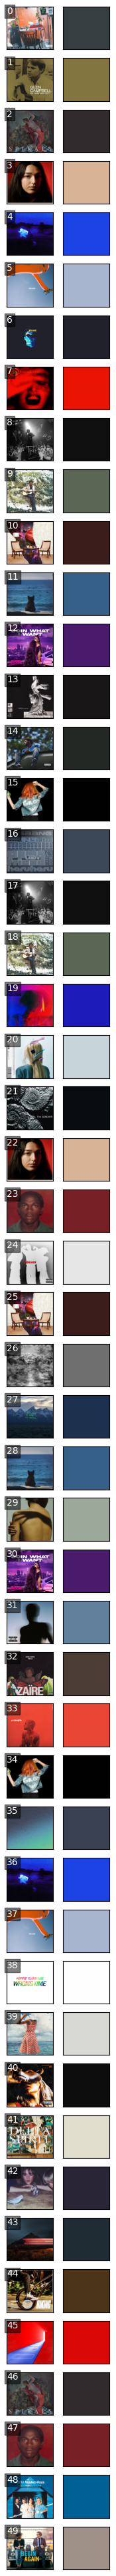

In [23]:
%matplotlib inline
fig, axs = plot_images(data, 'color_2')

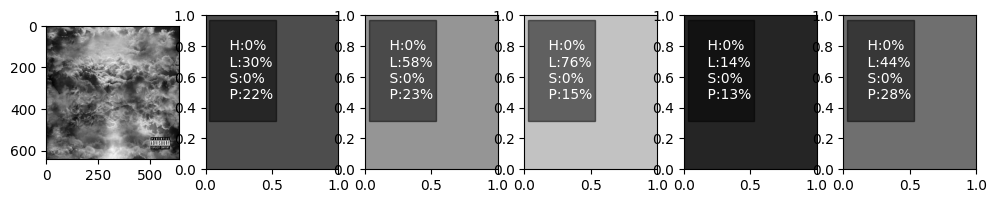

In [24]:
# Individual checks
song = data.iloc[26]

img = load_image(song.image_url)
palette, proportions = get_color_palette(song.image_url)
hls = [colorsys.rgb_to_hls(*x) for x in np.array(palette)/255]

fig, axs = plt.subplots(1, 6, figsize=(12,2))
axs = np.array(axs).flatten()
axs[0].imshow(img)
for i,rgb in enumerate(palette,1):
    ax = axs[i]
    ax.set_facecolor(np.array(rgb)/255)
    text = f"""
    H:{hls[i-1][0]:,.0%}
    L:{hls[i-1][1]:,.0%}
    S:{hls[i-1][2]:,.0%}
    P:{proportions[i-1]:,.0%}
    """
    ax.text(0.05,0.95,text, va='top', color='white',bbox=dict(facecolor='black',alpha=0.5,pad=2))

## Sorting

In [26]:
data['color'] = data.image_url.apply(get_color, s_threshold=0.1,l_threshold_range=(0.15,0.85),p_threshold=0.15)

In [ ]:
def classify_color(rgb:list):
    h,l,s = colorsys.rgb_to_hls(*np.array(rgb) / 255)
    if l < 0.1:
        return 'dark'
    if l > 0.9:
        return 'light'
    if s < 0.03:
        return 'gray'
    return 'color'

In [31]:
def color_to_hsl_encoded(color:list):
    h, l, s = colorsys.rgb_to_hls(*np.array(color) / 255)
    return {
        'h_sin': np.sin(2 * np.pi * h),
        'h_cos': np.cos(2 * np.pi * h),
        's': s,
        'l': l
    }

In [32]:
data['color_key'] = data['color'].apply(classify_color)

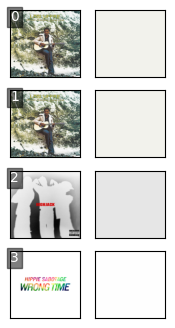

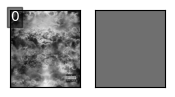

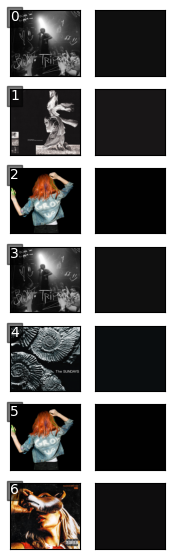

In [34]:
lights = data[data.color_key == 'light'].reset_index()
darks = data[data.color_key == 'dark'].reset_index()
grays = data[data.color_key == 'gray'].reset_index()
colors = data[data.color_key == 'color'].reset_index()

fig, axs = plot_images(lights, 'color')
fig, axs = plot_images(grays, 'color')
fig, axs = plot_images(darks, 'color')

In [39]:
features = colors.color.apply(lambda x: pd.Series(color_to_hsl_encoded(x)))

n_clusters = 5
km = KMeans(n_clusters=n_clusters, random_state=42)
feature_labels = km.fit_predict(features)
colors['feature_labels'] = feature_labels

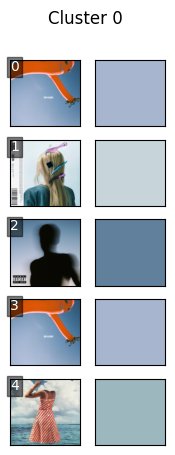

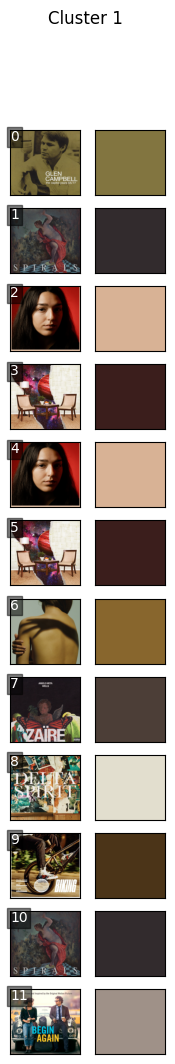

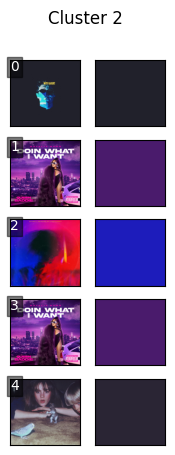

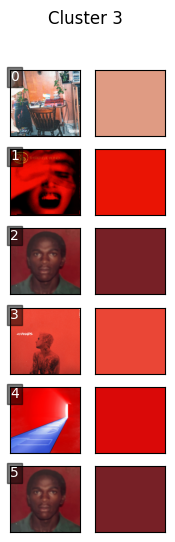

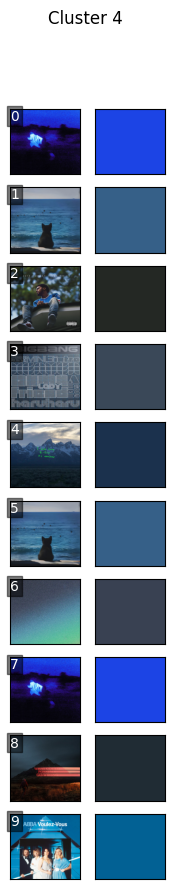

In [42]:
for c in sorted(list(colors['feature_labels'].unique())):
    tmp = colors[colors['feature_labels']==c].reset_index()
    fig, axs = plot_images(tmp, 'color')
    fig.suptitle(f'Cluster {c}')

## Final Config
Get Color
- s_threshold=0.1 and l_threshold_range=(0.15,0.85): capture more vibrant colors without pulling in grayish, dark, and light colors
- p_threshold=0.15: vibrant color is only extracted if it makes up a sizable portion of the image